## **압입 및 압축 시험 실험 결과 분석**

기계시스템공학실험(B) 고체생산 4주차

---
`indent_30mm`: 직경 30mm 반구형 압입자로 누른 압입 시험 데이터

`indent_45mm`: 직경 45mm 반구형 압입자로 누른 압입 시험 데이터

`comp` : 고무 시편의 압축 시험 데이터
<br><br>

실험 분석을 위해 사용한 라이브러리 및 용도는 다음과 같습니다.


`pandas`: csv 형태의 데이터를 처리하기 위해 사용하였다.

`matplotlib`: Python의 시각화 라이브러리로, 각종 선도(Curve)의 시각화를 위해 사용하였다.

`scipy`: '하중-변위 선도'의 Curve Fitting을 위해 사용하였다.

<br><br>
이외 자세한 실험 과정 및 결과는 실험 보고서를 참고 바랍니다.

In [173]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

indent_30mm = pd.read_csv("D:/00 기계공학실험/고체 생산/indentation_30mm_B04_02.csv", encoding='euc-kr')
indent_45mm = pd.read_csv("D:/00 기계공학실험/고체 생산/indentation_45mm_B04_02.csv", encoding='euc-kr')
comp = pd.read_csv("D:/00 기계공학실험/고체 생산/Compression_B04_02.csv", encoding='euc-kr')

display(indent_30mm.tail())
display(indent_45mm.tail())

,일련번호,시간,하중,변위,강도,변형율
872,872.0,89.535,59.600000,2.980000,59.599998,1.886076
873,873.0,89.589,59.600000,2.990000,59.599998,1.892405
874,874.0,89.668,59.700000,2.990000,59.700001,1.892405
875,875.0,89.807,59.800000,2.990000,59.799999,1.892405
876,876.0,89.885,59.900000,2.990000,59.900002,1.892405


,일련번호,시간,하중,변위,강도,변형율
859,859.0,89.627,56.500000,2.990000,56.500000,1.892405
860,860.0,89.651,56.600000,2.990000,56.599998,1.892405
861,861.0,89.723,56.700000,2.990000,56.700001,1.892405
862,862.0,89.902,56.800000,2.990000,56.799999,1.892405
863,863.0,89.925,56.800000,3.000000,56.799999,1.898734


### **30mm 곡률반경 압입시험**

30mm 직경의 반구형 압입자를 사용한 압입시험에서 '하중-변위 선도'를 도식하여

Curve Fitting을 통하여 미지의 영률 E를 계산한다.

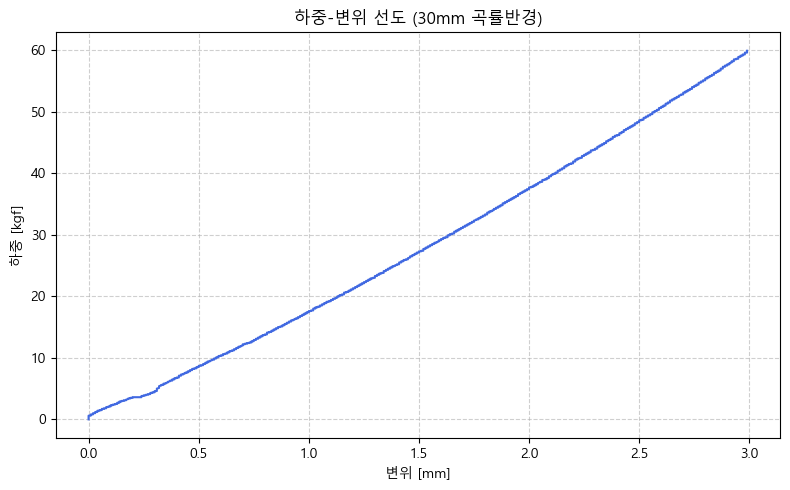

In [174]:
indent_30mm = indent_30mm.drop(0).reset_index(drop=True)

x = pd.to_numeric(indent_30mm['변위'])
y = pd.to_numeric(indent_30mm['하중'])

## 그래프
plt.figure(figsize=(8, 5))
plt.plot(x, y, color='royalblue', linewidth=1.5)

plt.title('하중-변위 선도 (30mm 곡률반경)')
plt.xlabel('변위 [mm]')
plt.ylabel('하중 [kgf]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

최적화된 E 값: 1.2931 kgf/mm²
최적화된 E 값 (MPa): 12.6809 MPa
R-squared (결정계수): 0.9594


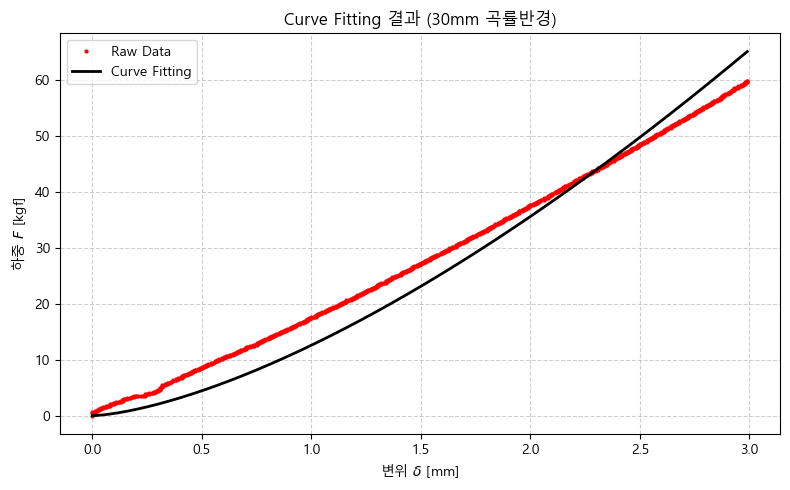

In [ ]:
from scipy.optimize import curve_fit

delta = pd.to_numeric(indent_30mm['변위']).values
F = pd.to_numeric(indent_30mm['하중']).values
R = 30.0  # mm 단위

def indentation_model(delta_val, E):
  return (16.0 / 9.0) * E * np.sqrt(R) * (delta_val ** 1.5)

# Least Squared Method를 이용한 Curve Fitting 
popt, pcov = curve_fit(indentation_model, delta, F)
E_fitted = popt[0]

print(f'최적화된 E 값: {E_fitted:.4f} kgf/mm²')
E_gpa = E_fitted * 9.80665
print(f'최적화된 E 값 (MPa): {E_gpa:.4f} MPa')

F_pred = indentation_model(delta, E_fitted)
ss_res = np.sum((F - F_pred) ** 2)  # 잔차 제곱합 
ss_tot = np.sum((F - np.mean(F)) ** 2)  # 총 제곱합 
r_squared = 1 - (ss_res / ss_tot)

print(f'R-squared (결정계수): {r_squared:.4f}')

## 그래프 
plt.figure(figsize=(8, 5))
plt.plot(delta, F, 'ro', markersize=2, label='Raw Data')
plt.plot(delta, F_pred,'k-', linewidth=2, label=f'Curve Fitting')

plt.title('Curve Fitting 결과 (30mm 곡률반경)')
plt.xlabel('변위 $\\delta$ [mm]')
plt.ylabel('하중 $F$ [kgf]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### **45mm 곡률반경 압입시험**

45mm 직경의 반구형 압입자를 사용한 압입시험에서 '하중-변위 선도'를 도식하여

Curve Fitting을 통하여 미지의 영률 E를 계산한다.

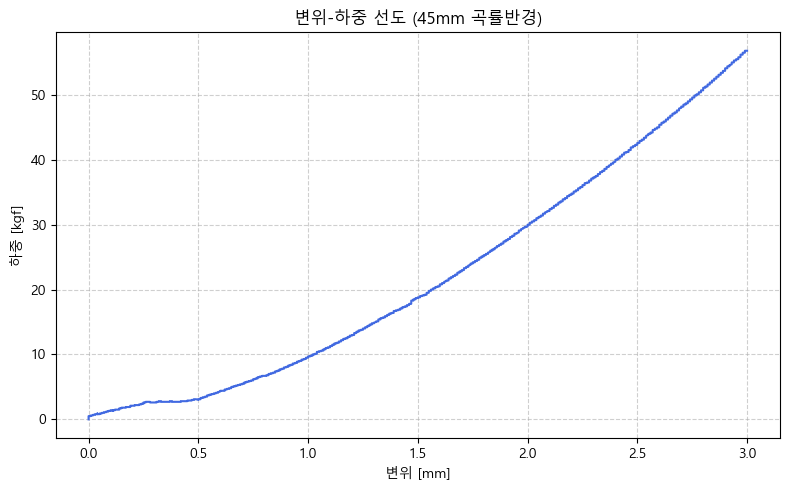

In [176]:
indent_45mm = indent_45mm.drop(0).reset_index(drop=True)

x = pd.to_numeric(indent_45mm['변위'])
y = pd.to_numeric(indent_45mm['하중'])

## 그래프
plt.figure(figsize=(8, 5))
plt.plot(x, y, color='royalblue', linewidth=1.5)

plt.title('변위-하중 선도 (45mm 곡률반경)')
plt.xlabel('변위 [mm]')
plt.ylabel('하중 [kgf]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

최적화된 E 값: 0.8976 kgf/mm²
최적화된 E 값 (MPa): 8.8029 MPa
R-squared (결정계수): 0.9979


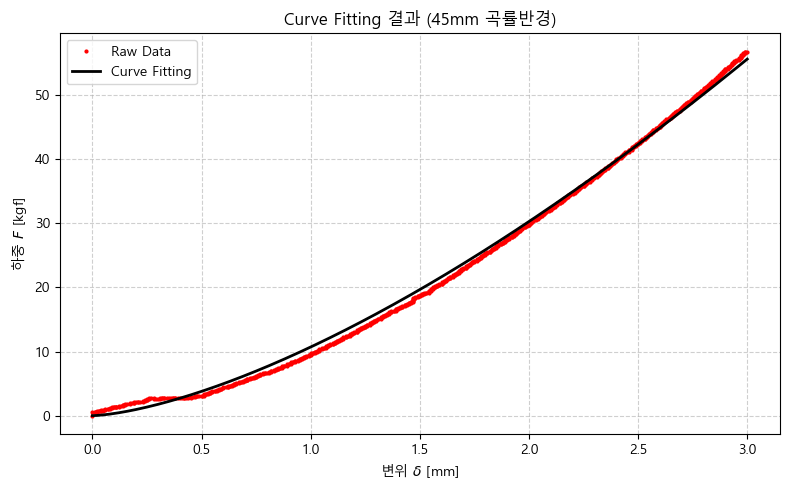

In [ ]:
delta = pd.to_numeric(indent_45mm['변위']).values
F = pd.to_numeric(indent_45mm['하중']).values
R = 45.0  # mm 단위

# Least Squared Method를 이용한 Curve Fitting
popt, pcov = curve_fit(indentation_model, delta, F)
E_fitted = popt[0]

print(f'최적화된 E 값: {E_fitted:.4f} kgf/mm²')
E_gpa = E_fitted * 9.80665
print(f'최적화된 E 값 (MPa): {E_gpa:.4f} MPa')

F_pred = indentation_model(delta, E_fitted)
ss_res = np.sum((F - F_pred) ** 2)  # 잔차 제곱합
ss_tot = np.sum((F - np.mean(F)) ** 2)  # 총 제곱합
r_squared = 1 - (ss_res / ss_tot)

print(f'R-squared (결정계수): {r_squared:.4f}')

# 6. 결과 시각화
plt.figure(figsize=(8, 5))
plt.plot(delta, F, 'ro', markersize=2, label='Raw Data')
plt.plot(delta, F_pred,'k-', linewidth=2, label=f'Curve Fitting')

plt.title('Curve Fitting 결과 (45mm 곡률반경)')
plt.xlabel('변위 $\\delta$ [mm]')
plt.ylabel('하중 $F$ [kgf]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

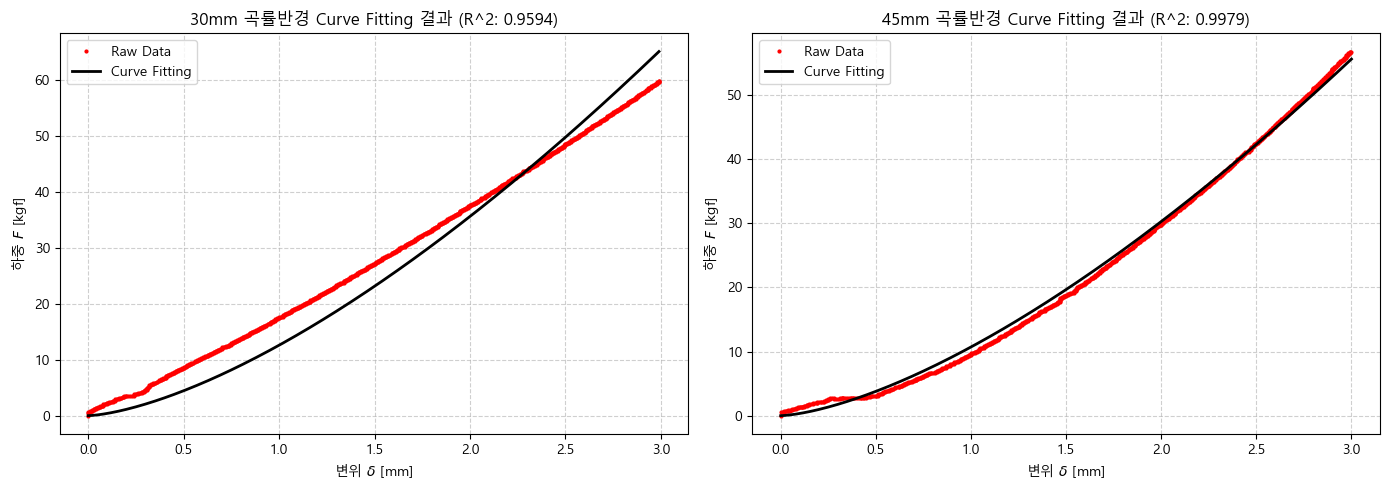

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

## 30mm 곡률반경
delta_30 = pd.to_numeric(indent_30mm['변위']).values
F_30 = pd.to_numeric(indent_30mm['하중']).values
R = 30.0  # mm 단위

popt_30, pcov_30 = curve_fit(indentation_model, delta_30, F_30)
E_fitted_30 = popt_30[0]

F_pred_30 = indentation_model(delta_30, E_fitted_30)
ss_res_30 = np.sum((F_30 - F_pred_30) ** 2)  # 잔차 제곱합
ss_tot_30 = np.sum((F_30 - np.mean(F_30)) ** 2)  # 총 제곱합
r_squared_30 = 1 - (ss_res_30 / ss_tot_30)

axes[0].plot(delta_30, F_30, 'ro', markersize=2, label='Raw Data')
axes[0].plot(delta_30, F_pred_30, 'k-', linewidth=2, label='Curve Fitting')
axes[0].set_title(f'30mm 곡률반경 Curve Fitting 결과 (R^2: {r_squared_30:.4f})')
axes[0].set_xlabel('변위 $\\delta$ [mm]')
axes[0].set_ylabel('하중 $F$ [kgf]')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

## 45mm 곡률반경
delta_45 = pd.to_numeric(indent_45mm['변위']).values
F_45 = pd.to_numeric(indent_45mm['하중']).values
R = 45.0  # mm 단위

popt_45, pcov_45 = curve_fit(indentation_model, delta_45, F_45)
E_fitted_45 = popt_45[0]

F_pred_45 = indentation_model(delta_45, E_fitted_45)
ss_res_45 = np.sum((F_45 - F_pred_45) ** 2)  # 잔차 제곱합
ss_tot_45 = np.sum((F_45 - np.mean(F_45)) ** 2)  # 총 제곱합
r_squared_45 = 1 - (ss_res_45 / ss_tot_45)

axes[1].plot(delta_45, F_45, 'ro', markersize=2, label='Raw Data')
axes[1].plot(delta_45, F_pred_45, 'k-', linewidth=2, label='Curve Fitting')
axes[1].set_title(f'45mm 곡률반경 Curve Fitting 결과 (R^2: {r_squared_45:.4f})')
axes[1].set_xlabel('변위 $\\delta$ [mm]')
axes[1].set_ylabel('하중 $F$ [kgf]')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

### **압축 시험 분석**

압축 시험에서 공칭 응력-변형률 선도에서의 그래프 기울기를 통해 영률을 구한다.

이때 Raw Data상에서 정확한 응력이 측정되지 않았다. (csv 파일 확인 결과, '강도'열과 '하중'열의 데이터가 동일함.)

따라서 측정한 초기 면적값을 토대로 공칭 응력을 계산하고, 이를 토대로 공칭 응력-변형률 선도를 도식한다.

In [ ]:
comp = comp.drop(0).reset_index(drop=True)

L0 = 158.0  # 초기 길이 (mm)
A0 = 100.0 * 100.0  # 단면적 (mm^2)

# 실제 응력과 변형률 계산, 전처리 과정
load = pd.to_numeric(comp['하중'])  # 하중 [kgf]
displacement = pd.to_numeric(comp['변위'])  # 변위 [mm]

comp['응력'] = load / A0  # [kgf/mm²]
comp['변형률'] = pd.to_numeric(comp['변형율']) / 100 # mm/mm 단위

comp.head()

,일련번호,시간,하중,변위,강도,변형율,응력,변형률
0,2.0,0.000,0.500000,0.000000,0.500000,0.000000,0.00005,0.000000
1,3.0,0.005,0.600000,0.000000,0.600000,0.000000,0.00006,0.000000
2,4.0,0.167,0.700000,0.000000,0.700000,0.000000,0.00007,0.000000
3,5.0,0.189,0.700000,0.010000,0.700000,0.006329,0.00007,0.000063
4,6.0,0.236,0.800000,0.010000,0.800000,0.006329,0.00008,0.000063


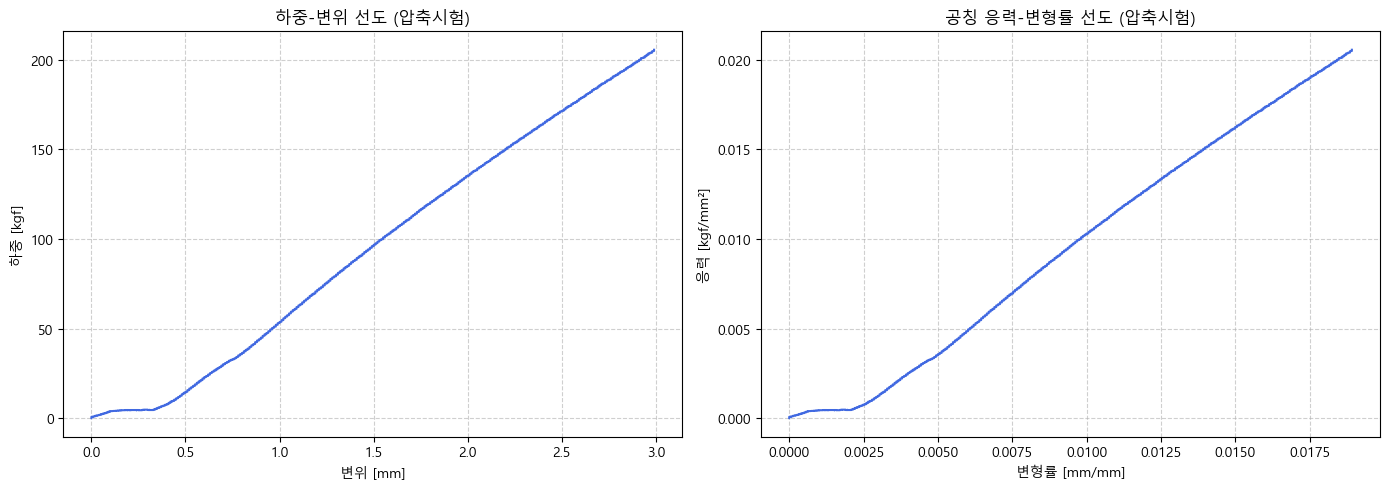

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

# 하중-변위 선도
axes[0].plot(
    displacement, load, color='royalblue', linewidth=1.5
)
axes[0].set_title('하중-변위 선도 (압축시험)')
axes[0].set_xlabel('변위 [mm]')
axes[0].set_ylabel('하중 [kgf]')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 응력-변형률 선도
axes[1].plot(
    comp['변형률'], comp['응력'], color='royalblue', linewidth=1.5
)
axes[1].set_title('공칭 응력-변형률 선도 (압축시험)')
axes[1].set_xlabel('변형률 [mm/mm]')
axes[1].set_ylabel('응력 [kgf/mm²]')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

변형률 | 0.006076 | 응력 | 0.0 kgf/mm²
변형률 | 0.009810 | 응력 | 0.0 kgf/mm²
변형률 | 0.013924 | 응력 | 0.0 kgf/mm²
계산된 영률(E): 1.2762 kgf/mm²
영률(E) MPa 환산: 12.5151 MPa


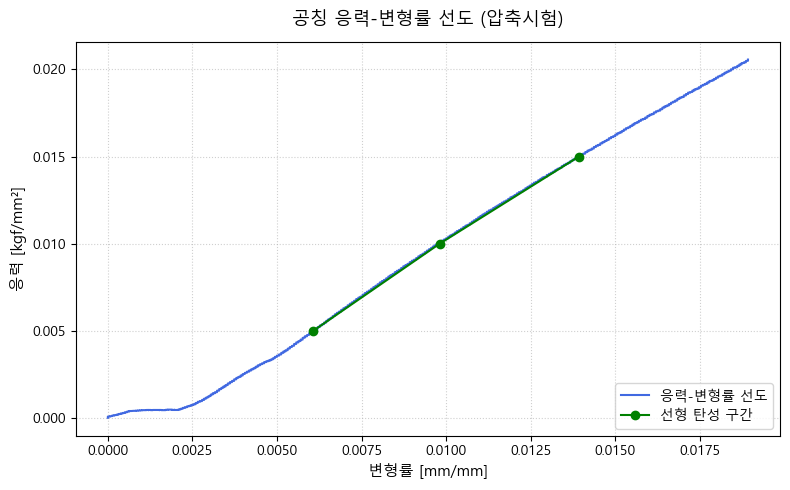

In [ ]:
# 선형 탄성 구간
target_stresses = [0.005, 0.010, 0.015]
target_strains = np.interp(target_stresses, comp['응력'], comp['변형률'])

e1, e2, e3 = target_strains
s1, s2, s3 = target_stresses

print(f'변형률 | {e1:.6f} | 응력 | {s1:.1f} kgf/mm²')
print(f'변형률 | {e2:.6f} | 응력 | {s2:.1f} kgf/mm²')
print(f'변형률 | {e3:.6f} | 응력 | {s3:.1f} kgf/mm²')

s_ab = (s2 - s1) / (e2 - e1)
s_bc = (s3 - s2) / (e3 - e2)
s_ac = (s3 - s1) / (e3 - e1)
E = (s_ab + s_bc + s_ac) / 3

print(f'계산된 영률(E): {E:.4f} kgf/mm²')
print(f'영률(E) MPa 환산: {E * 9.80665 :.4f} MPa')  # 단위 환산 계수 적용

## 그래프
plt.figure(figsize=(8, 5), dpi=100)
plt.plot(comp['변형률'], comp['응력'], color='royalblue', linewidth=1.5, label='응력-변형률 선도')
plt.plot(target_strains, target_stresses, 'go-', linewidth=1.5, markersize=6, label='선형 탄성 구간')
plt.title('공칭 응력-변형률 선도 (압축시험)', fontsize=13, pad=12)
plt.xlabel('변형률 [mm/mm]', fontsize=11)
plt.ylabel('응력 [kgf/mm²]', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()